# Q5 historical descriptive analysis

**Research question**

Over the next six years, how will the proportion of people in London’s boroughs who regularly volunteer in sport change across different age groups and activity levels (inactive, fairly active and active)? Do the predicted differences between people with different activity levels vary by age group?

This notebook describes the six historical survey years before forecasting.
It focuses on volunteering frequency, age group, activity level and borough variation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter


DATA_DIR = Path(".")
Q5_OUTPUT_DIR = DATA_DIR

FIGURE_DIR = (
    Q5_OUTPUT_DIR
    / "descriptive_figures"
)

TABLE_DIR = (
    Q5_OUTPUT_DIR
    / "descriptive_tables"
)

RESPONDENT_PATH = (
    Q5_OUTPUT_DIR
    / "q5_respondent_master_with_variables.csv"
)

COMPLETE_PANEL_PATH = (
    Q5_OUTPUT_DIR
    / "q5_versionA_borough_age_activitylevel_panel_complete.csv"
)

WEIGHT_COL = "wt_final_online"

YEAR_ORDER = [3, 4, 5, 6, 7, 8]

YEAR_LABELS = {
    3: "Year 3",
    4: "Year 4",
    5: "Year 5",
    6: "Year 6",
    7: "Year 7",
    8: "Year 8",
}

AGE_ORDER = [
    "16-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65-74",
    "75-84",
    "85+",
]

ACTIVITY_ORDER = [
    "inactive",
    "fairly_active",
    "active",
]

ACTIVITY_DISPLAY = {
    "inactive": "Inactive",
    "fairly_active": "Fairly active",
    "active": "Active",
}

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not RESPONDENT_PATH.exists():
    raise FileNotFoundError(
        f"File not found: {RESPONDENT_PATH}"
    )

if not COMPLETE_PANEL_PATH.exists():
    raise FileNotFoundError(
        f"File not found: {COMPLETE_PANEL_PATH}"
    )

respondents = pd.read_csv(
    RESPONDENT_PATH,
    low_memory=False,
)

complete_panel = pd.read_csv(
    COMPLETE_PANEL_PATH,
    low_memory=False,
)

print(
    f"Respondent master: "
    f"{respondents.shape[0]:,} rows, "
    f"{respondents.shape[1]} columns"
)

print(
    f"Complete panel: "
    f"{complete_panel.shape[0]:,} rows, "
    f"{complete_panel.shape[1]} columns"
)

def parse_nullable_boolean(series):
    text_values = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return text_values.map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    ).astype("boolean")


boolean_columns = [
    "small_cell",
    "few_frequent_cases",
    "zero_frequent_cases",
    "cell_observed",
    "rate_available",
    "series_has_history",
    "series_complete_history",
]

for column in boolean_columns:
    complete_panel[column] = (
        parse_nullable_boolean(
            complete_panel[column]
        )
    )

Respondent master: 96,629 rows, 13 columns
Complete panel: 4,608 rows, 26 columns


In [2]:
required_respondent_columns = [
    "year",
    "LA_2023",
    "age_group_code",
    "age_group",
    "activity_level_3cat",
    "activity_level_3cat_label",
    "vol_binary_A",
    WEIGHT_COL,
]

missing_columns = [
    column
    for column in required_respondent_columns
    if column not in respondents.columns
]

if missing_columns:
    raise ValueError(
        f"Missing respondent columns: "
        f"{missing_columns}"
    )

numeric_columns = [
    "year",
    "LA_2023",
    "age_group_code",
    "activity_level_3cat",
    "vol_binary_A",
    WEIGHT_COL,
]

for column in numeric_columns:
    respondents[column] = pd.to_numeric(
        respondents[column],
        errors="coerce",
    )
    
eligible = (
    respondents["year"].isin(YEAR_ORDER)
    & respondents["LA_2023"].notna()
    & respondents["age_group"].isin(
        AGE_ORDER
    )
    & respondents[
        "activity_level_3cat_label"
    ].isin(ACTIVITY_ORDER)
    & respondents["vol_binary_A"].isin(
        [0, 1]
    )
    & respondents[WEIGHT_COL].notna()
    & (respondents[WEIGHT_COL] > 0)
)

analysis_sample = respondents.loc[
    eligible
].copy()

analysis_sample["weighted_frequent"] = (
    analysis_sample[WEIGHT_COL]
    * analysis_sample["vol_binary_A"]
)

analysis_sample["weight_squared"] = (
    analysis_sample[WEIGHT_COL] ** 2
)

analysis_sample["age_group"] = (
    pd.Categorical(
        analysis_sample["age_group"],
        categories=AGE_ORDER,
        ordered=True,
    )
)

analysis_sample[
    "activity_level_3cat_label"
] = pd.Categorical(
    analysis_sample[
        "activity_level_3cat_label"
    ],
    categories=ACTIVITY_ORDER,
    ordered=True,
)

complete_panel["age_group"] = (
    pd.Categorical(
        complete_panel["age_group"],
        categories=AGE_ORDER,
        ordered=True,
    )
)

complete_panel[
    "activity_level_3cat_label"
] = pd.Categorical(
    complete_panel[
        "activity_level_3cat_label"
    ],
    categories=ACTIVITY_ORDER,
    ordered=True,
)

observed_panel = complete_panel.loc[
    complete_panel[
        "cell_observed"
    ].fillna(False)
].copy()

print(
    f"Eligible respondent rows: "
    f"{len(analysis_sample):,}"
)

print(
    f"Observed cells: "
    f"{len(observed_panel):,}"
)

print(
    f"Unobserved cells: "
    f"{len(complete_panel) - len(observed_panel):,}"
)

print(
    f"Boroughs: "
    f"{analysis_sample['LA_2023'].nunique()}"
)

Eligible respondent rows: 58,850
Observed cells: 4,127
Unobserved cells: 481
Boroughs: 32


In [3]:
def calculate_weighted_rate(
    data,
    group_columns,
):
    summary = (
        data
        .groupby(
            group_columns,
            observed=True,
            dropna=False,
        )
        .agg(
            n=(
                "vol_binary_A",
                "size",
            ),
            n_frequent=(
                "vol_binary_A",
                "sum",
            ),
            weighted_n=(
                WEIGHT_COL,
                "sum",
            ),
            weighted_frequent=(
                "weighted_frequent",
                "sum",
            ),
            sum_weight_squared=(
                "weight_squared",
                "sum",
            ),
        )
        .reset_index()
    )

    summary["n_frequent"] = (
        summary["n_frequent"]
        .astype(int)
    )

    summary["n_not_frequent"] = (
        summary["n"]
        - summary["n_frequent"]
    )

    summary[
        "frequent_volunteer_rate"
    ] = (
        summary["weighted_frequent"]
        / summary["weighted_n"]
    )

    summary["effective_n"] = (
        summary["weighted_n"] ** 2
        / summary["sum_weight_squared"]
    )

    summary["small_cell"] = (
        summary["n"] < 30
    )

    summary["few_frequent_cases"] = (
        summary["n_frequent"] < 5
    )

    if not summary[
        "frequent_volunteer_rate"
    ].between(0, 1).all():
        raise ValueError(
            "A weighted rate falls outside "
            "the interval [0, 1]."
        )

    return summary

def save_figure(
    fig,
    filename,
):
    output_path = (
        FIGURE_DIR
        / filename
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"Saved figure: "
        f"{output_path}"
    )

In [4]:
dataset_overview = pd.DataFrame(
    {
        "measure": [
            "Eligible respondents",
            "Historical years",
            "Boroughs",
            "Observed cells",
            "Unobserved cells",
            "Total series",
            "Complete six-year series",
        ],
        "value": [
            len(analysis_sample),
            analysis_sample[
                "year"
            ].nunique(),
            analysis_sample[
                "LA_2023"
            ].nunique(),
            len(observed_panel),
            (
                len(complete_panel)
                - len(observed_panel)
            ),
            complete_panel[
                "series_id"
            ].nunique(),
            complete_panel.loc[
                complete_panel[
                    "series_complete_history"
                ].fillna(False),
                "series_id",
            ].nunique(),
        ],
    }
)

print(
    dataset_overview.to_string(
        index=False
    )
)

dataset_overview

                 measure  value
    Eligible respondents  58850
        Historical years      6
                Boroughs     32
          Observed cells   4127
        Unobserved cells    481
            Total series    768
Complete six-year series    570


,measure,value
0,Eligible respondents,58850
1,Historical years,6
2,Boroughs,32
3,Observed cells,4127
4,Unobserved cells,481
5,Total series,768
6,Complete six-year series,570


In [5]:
cell_quality_overview = pd.DataFrame(
    {
        "measure": [
            "Median raw cell size",
            "Median effective sample size",
            "Small-cell rate",
            "Few-frequent-case rate",
            "Zero-frequent-case rate",
        ],
        "value": [
            observed_panel[
                "n_parent_cell"
            ].median(),
            observed_panel[
                "effective_n_parent_cell"
            ].median(),
            observed_panel[
                "small_cell"
            ].mean(),
            observed_panel[
                "few_frequent_cases"
            ].mean(),
            observed_panel[
                "zero_frequent_cases"
            ].mean(),
        ],
    }
)

print(
    cell_quality_overview.to_string(
        index=False
    )
)

cell_quality_overview

                     measure    value
        Median raw cell size 8.000000
Median effective sample size 5.550681
             Small-cell rate 0.853162
      Few-frequent-case rate 0.889024
     Zero-frequent-case rate 0.490187


,measure,value
0,Median raw cell size,8.000000
1,Median effective sample size,5.550681
2,Small-cell rate,0.853162
3,Few-frequent-case rate,0.889024
4,Zero-frequent-case rate,0.490187


In [6]:
quality_by_age_activity = (
    observed_panel
    .groupby(
        [
            "age_group_code",
            "age_group",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
        observed=True,
    )
    .agg(
        observed_cells=(
            "series_id",
            "size",
        ),
        median_raw_n=(
            "n_parent_cell",
            "median",
        ),
        median_effective_n=(
            "effective_n_parent_cell",
            "median",
        ),
        small_cell_rate=(
            "small_cell",
            "mean",
        ),
        few_frequent_cases_rate=(
            "few_frequent_cases",
            "mean",
        ),
        zero_frequent_cases_rate=(
            "zero_frequent_cases",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "age_group_code",
            "activity_level_3cat",
        ]
    )
)

quality_by_age_activity

,age_group_code,age_group,activity_level_3cat,activity_level_3cat_label,observed_cells,median_raw_n,median_effective_n,small_cell_rate,few_frequent_cases_rate,zero_frequent_cases_rate
0,2,16-24,0,inactive,179,6.0,4.586736,1.0,0.994413,0.49162
1,2,16-24,1,fairly_active,172,3.0,2.263772,1.0,0.994186,0.715116
2,2,16-24,2,active,192,18.0,12.977891,0.822917,0.765625,0.104167
3,3,25-34,0,inactive,192,12.0,8.016710,0.96875,0.984375,0.552083
4,3,25-34,1,fairly_active,188,7.0,4.651540,1.0,1.0,0.617021
5,3,25-34,2,active,192,39.0,25.198140,0.302083,0.59375,0.057292
6,4,35-44,0,inactive,192,13.5,8.693108,0.927083,0.994792,0.489583
7,4,35-44,1,fairly_active,192,8.0,5.327423,1.0,1.0,0.578125
8,4,35-44,2,active,192,49.0,31.894955,0.197917,0.479167,0.020833
9,5,45-54,0,inactive,191,10.0,6.648056,0.994764,0.989529,0.554974


Figure 1: effective sample size heatmap

Saved figure: descriptive_figures/figure_01_effective_n_heatmap.png


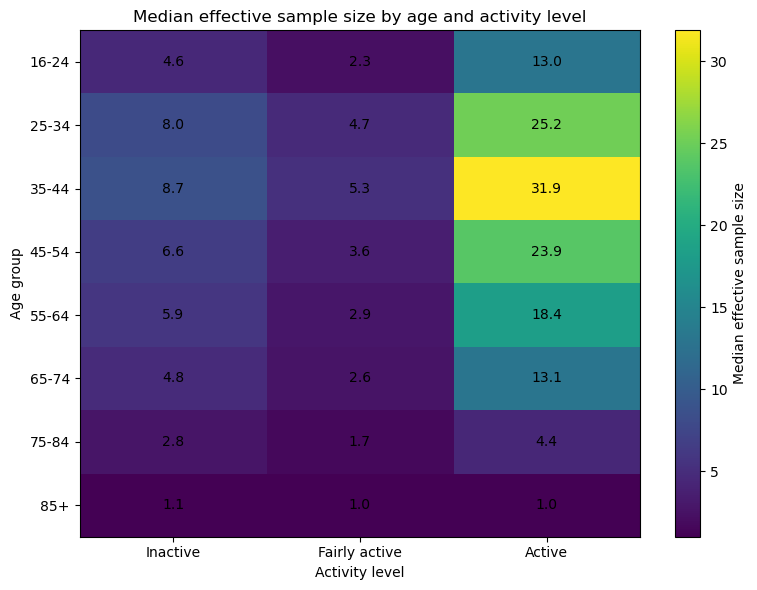

In [7]:
effective_n_matrix = (
    quality_by_age_activity
    .pivot(
        index="age_group",
        columns=(
            "activity_level_3cat_label"
        ),
        values="median_effective_n",
    )
    .reindex(
        index=AGE_ORDER,
        columns=ACTIVITY_ORDER,
    )
)

effective_n_matrix

fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    effective_n_matrix.to_numpy(),
    aspect="auto",
)

ax.set_xticks(
    range(len(ACTIVITY_ORDER))
)

ax.set_xticklabels(
    [
        ACTIVITY_DISPLAY[value]
        for value in ACTIVITY_ORDER
    ]
)

ax.set_yticks(
    range(len(AGE_ORDER))
)

ax.set_yticklabels(
    AGE_ORDER
)

for row_index in range(
    effective_n_matrix.shape[0]
):
    for column_index in range(
        effective_n_matrix.shape[1]
    ):
        value = effective_n_matrix.iloc[
            row_index,
            column_index,
        ]

        if pd.notna(value):
            ax.text(
                column_index,
                row_index,
                f"{value:.1f}",
                ha="center",
                va="center",
            )

ax.set_title(
    "Median effective sample size by "
    "age and activity level"
)

ax.set_xlabel(
    "Activity level"
)

ax.set_ylabel(
    "Age group"
)

fig.colorbar(
    image,
    ax=ax,
    label=(
        "Median effective sample size"
    ),
)

fig.tight_layout()

save_figure(
    fig,
    "figure_01_effective_n_heatmap.png",
)

plt.show()

Figure 2: London annual historical trend

Saved figure: descriptive_figures/figure_02_london_trend_by_activity.png


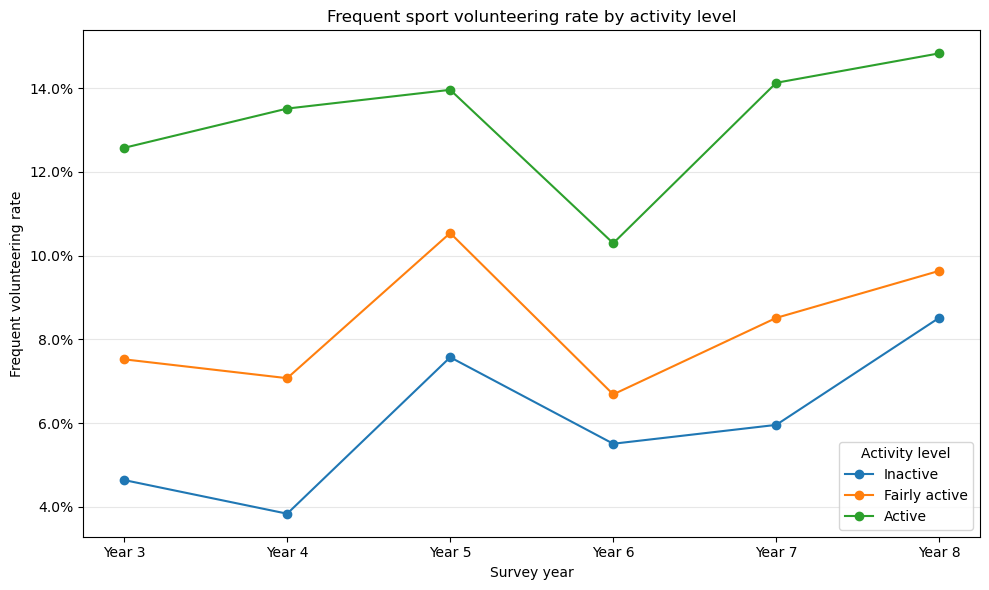

In [8]:
london_year_activity = (
    calculate_weighted_rate(
        data=analysis_sample,
        group_columns=[
            "year",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
    )
    .sort_values(
        [
            "year",
            "activity_level_3cat",
        ]
    )
)

london_year_activity[
    "year_label"
] = london_year_activity[
    "year"
].map(YEAR_LABELS)

london_year_activity

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for activity_level in ACTIVITY_ORDER:
    subset = (
        london_year_activity.loc[
            london_year_activity[
                "activity_level_3cat_label"
            ]
            == activity_level
        ]
        .sort_values("year")
    )

    ax.plot(
        subset["year"],
        subset[
            "frequent_volunteer_rate"
        ],
        marker="o",
        label=(
            ACTIVITY_DISPLAY[
                activity_level
            ]
        ),
    )

ax.set_xticks(
    YEAR_ORDER
)

ax.set_xticklabels(
    [
        YEAR_LABELS[year]
        for year in YEAR_ORDER
    ]
)

ax.set_title(
    "Frequent sport volunteering rate "
    "by activity level"
)

ax.set_xlabel(
    "Survey year"
)

ax.set_ylabel(
    "Frequent volunteering rate"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.legend(
    title="Activity level"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

save_figure(
    fig,
    "figure_02_london_trend_by_activity.png",
)

plt.show()

In [9]:
age_year_activity = (
    calculate_weighted_rate(
        data=analysis_sample,
        group_columns=[
            "year",
            "age_group_code",
            "age_group",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
    )
    .sort_values(
        [
            "year",
            "age_group_code",
            "activity_level_3cat",
        ]
    )
)

age_year_activity.head()

,year,age_group_code,age_group,activity_level_3cat,activity_level_3cat_label,n,n_frequent,weighted_n,weighted_frequent,sum_weight_squared,n_not_frequent,frequent_volunteer_rate,effective_n,small_cell,few_frequent_cases
0,3,2.0,16-24,0,inactive,79,7,185.552001,13.915042,749.852779,72,0.074993,45.915073,False,False
1,3,2.0,16-24,1,fairly_active,47,5,109.920510,17.205272,400.338369,42,0.156525,30.180766,False,False
2,3,2.0,16-24,2,active,325,47,817.685714,154.706542,3294.120846,278,0.189200,202.970673,False,False
3,3,3.0,25-34,0,inactive,178,8,337.101162,18.416168,1134.621475,170,0.054631,100.154277,False,False
4,3,3.0,25-34,1,fairly_active,114,6,230.599210,11.243642,785.321277,108,0.048758,67.712409,False,False


Figure 3：Average annual frequent volunteering rate by age and activity level
Annual survey-weighted rates were first calculated separately for each survey year. The displayed historical average gives equal weight to each of the six annual estimates.

Saved figure: descriptive_figures/figure_03_age_activity_profile.png


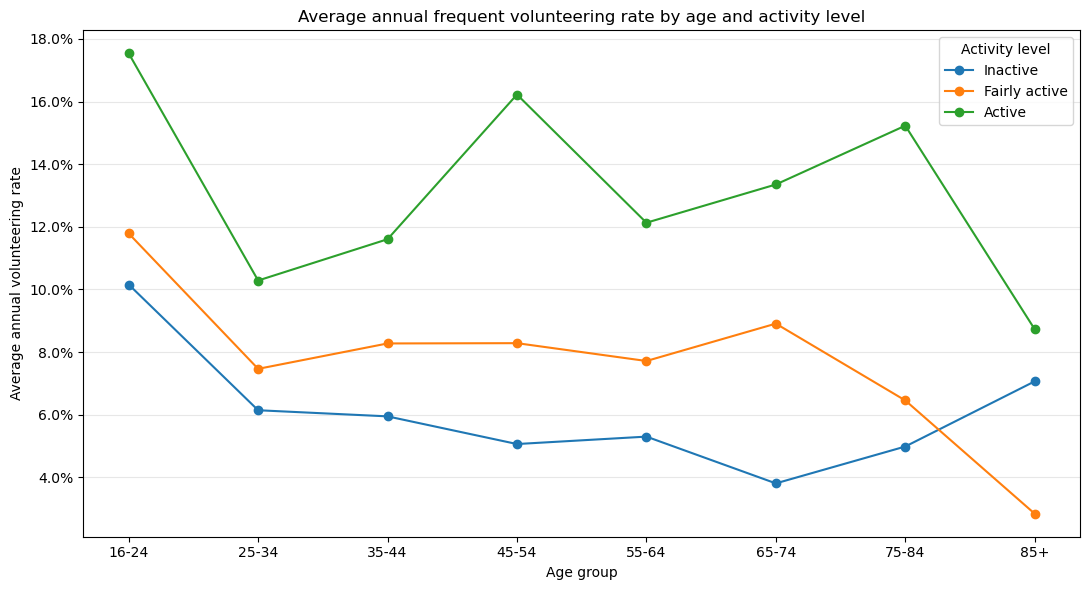

In [10]:
age_activity_average = (
    age_year_activity
    .groupby(
        [
            "age_group_code",
            "age_group",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
        observed=True,
    )
    .agg(
        average_annual_rate=(
            "frequent_volunteer_rate",
            "mean",
        ),
        observed_years=(
            "year",
            "nunique",
        ),
        median_effective_n=(
            "effective_n",
            "median",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "age_group_code",
            "activity_level_3cat",
        ]
    )
)

age_activity_average

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for activity_level in ACTIVITY_ORDER:
    subset = (
        age_activity_average.loc[
            age_activity_average[
                "activity_level_3cat_label"
            ]
            == activity_level
        ]
        .sort_values(
            "age_group_code"
        )
    )

    ax.plot(
        subset["age_group"].astype(str),
        subset["average_annual_rate"],
        marker="o",
        label=(
            ACTIVITY_DISPLAY[
                activity_level
            ]
        ),
    )

ax.set_title(
    "Average annual frequent volunteering "
    "rate by age and activity level"
)

ax.set_xlabel(
    "Age group"
)

ax.set_ylabel(
    "Average annual volunteering rate"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.legend(
    title="Activity level"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

save_figure(
    fig,
    "figure_03_age_activity_profile.png",
)

plt.show()

In [11]:
age_rate_wide = (
    age_year_activity
    .pivot_table(
        index=[
            "year",
            "age_group_code",
            "age_group",
        ],
        columns=(
            "activity_level_3cat_label"
        ),
        values=(
            "frequent_volunteer_rate"
        ),
        observed=True,
    )
    .reset_index()
)

age_rate_wide[
    "active_inactive_gap"
] = (
    age_rate_wide["active"]
    - age_rate_wide["inactive"]
)

age_rate_wide[
    "fairly_inactive_gap"
] = (
    age_rate_wide["fairly_active"]
    - age_rate_wide["inactive"]
)

age_rate_wide.head()

activity_level_3cat_label,year,age_group_code,age_group,inactive,fairly_active,active,active_inactive_gap,fairly_inactive_gap
0,3,2.0,16-24,0.074993,0.156525,0.189200,0.114208,0.081532
1,3,3.0,25-34,0.054631,0.048758,0.093297,0.038666,-0.005873
2,3,4.0,35-44,0.041062,0.055169,0.095800,0.054738,0.014107
3,3,5.0,45-54,0.051919,0.063703,0.175609,0.123690,0.011785
4,3,6.0,55-64,0.031928,0.077225,0.109322,0.077395,0.045297


In [12]:
def plot_gap_heatmap(
    data,
    gap_column,
    title,
    filename,
):
    matrix = (
        data
        .pivot(
            index="age_group",
            columns="year",
            values=gap_column,
        )
        .reindex(
            index=AGE_ORDER,
            columns=YEAR_ORDER,
        )
        * 100
    )

    values = matrix.to_numpy()
    finite_values = values[
        np.isfinite(values)
    ]

    colour_limit = max(
        np.abs(finite_values).max(),
        1.0,
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    image = ax.imshow(
        values,
        aspect="auto",
        cmap="coolwarm",
        vmin=-colour_limit,
        vmax=colour_limit,
    )

    ax.set_xticks(
        range(len(YEAR_ORDER))
    )

    ax.set_xticklabels(
        [
            YEAR_LABELS[year]
            for year in YEAR_ORDER
        ]
    )

    ax.set_yticks(
        range(len(AGE_ORDER))
    )

    ax.set_yticklabels(
        AGE_ORDER
    )

    for row_index in range(
        matrix.shape[0]
    ):
        for column_index in range(
            matrix.shape[1]
        ):
            value = matrix.iloc[
                row_index,
                column_index,
            ]

            if pd.notna(value):
                ax.text(
                    column_index,
                    row_index,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                )

    ax.set_title(title)

    ax.set_xlabel(
        "Survey year"
    )

    ax.set_ylabel(
        "Age group"
    )

    fig.colorbar(
        image,
        ax=ax,
        label=(
            "Percentage-point difference"
        ),
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )

    plt.show()

Saved figure: descriptive_figures/figure_04_active_inactive_gap_heatmap.png


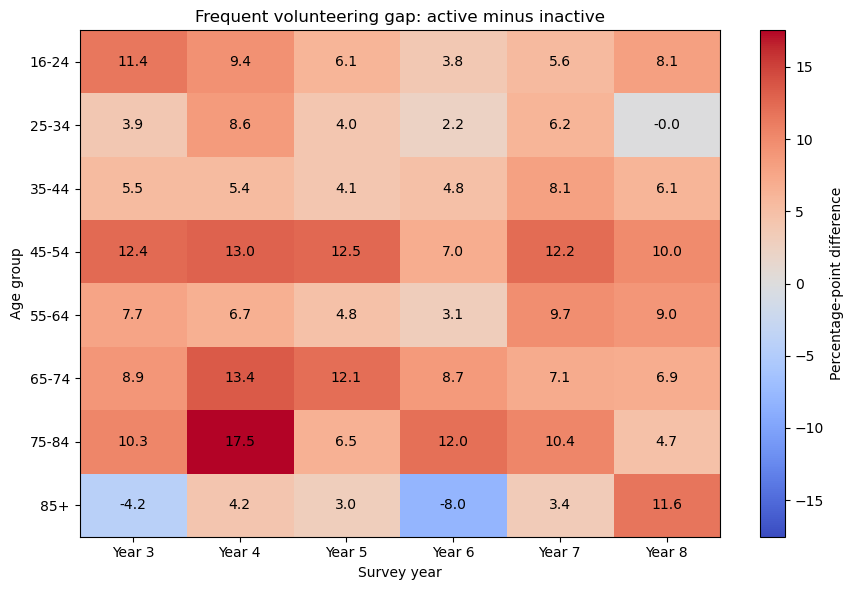

In [13]:
plot_gap_heatmap(
    data=age_rate_wide,
    gap_column=(
        "active_inactive_gap"
    ),
    title=(
        "Frequent volunteering gap: "
        "active minus inactive"
    ),
    filename=(
        "figure_04_active_inactive_"
        "gap_heatmap.png"
    ),
)

Saved figure: descriptive_figures/figure_05_fairly_inactive_gap_heatmap.png


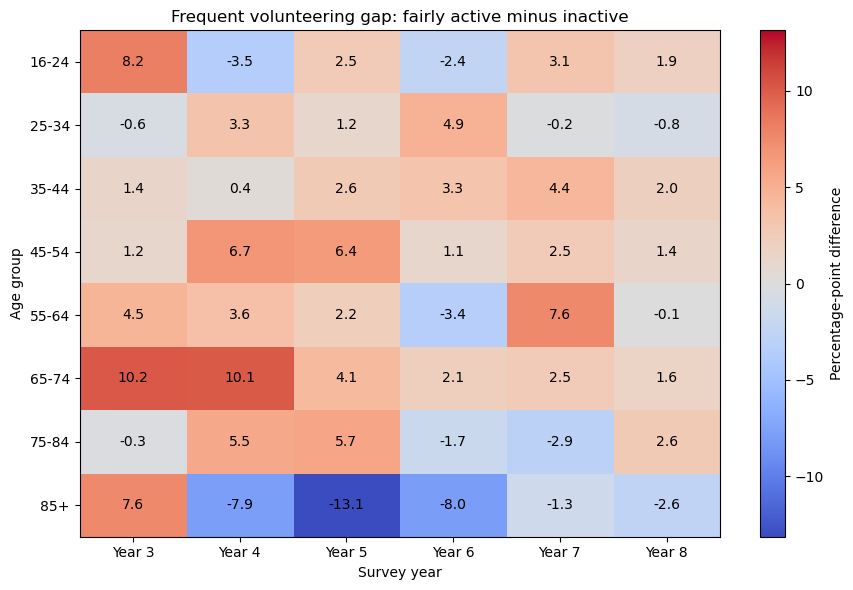

In [14]:
plot_gap_heatmap(
    data=age_rate_wide,
    gap_column=(
        "fairly_inactive_gap"
    ),
    title=(
        "Frequent volunteering gap: "
        "fairly active minus inactive"
    ),
    filename=(
        "figure_05_fairly_inactive_"
        "gap_heatmap.png"
    ),
)

In [15]:
borough_year_activity = (
    calculate_weighted_rate(
        data=analysis_sample,
        group_columns=[
            "year",
            "LA_2023",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
    )
    .sort_values(
        [
            "year",
            "LA_2023",
            "activity_level_3cat",
        ]
    )
)

borough_year_activity.head()

,year,LA_2023,activity_level_3cat,activity_level_3cat_label,n,n_frequent,weighted_n,weighted_frequent,sum_weight_squared,n_not_frequent,frequent_volunteer_rate,effective_n,small_cell,few_frequent_cases
0,3,8,0,inactive,41,0,69.106128,0.000000,255.727150,41,0.000000,18.674814,False,True
1,3,8,1,fairly_active,16,0,18.942499,0.000000,33.184977,16,0.000000,10.812672,True,True
2,3,8,2,active,71,8,88.493973,9.094418,181.308412,63,0.102769,43.192609,False,False
3,3,9,0,inactive,28,1,72.913632,1.489127,440.981228,27,0.020423,12.055837,True,True
4,3,9,1,fairly_active,17,0,41.024429,0.000000,181.128003,17,0.000000,9.291792,True,True


In [16]:
borough_rate_wide = (
    borough_year_activity
    .pivot_table(
        index=[
            "year",
            "LA_2023",
        ],
        columns=(
            "activity_level_3cat_label"
        ),
        values=(
            "frequent_volunteer_rate"
        ),
        observed=True,
    )
    .reset_index()
)

borough_rate_wide[
    "active_inactive_gap"
] = (
    borough_rate_wide["active"]
    - borough_rate_wide["inactive"]
)

borough_rate_wide[
    "fairly_inactive_gap"
] = (
    borough_rate_wide[
        "fairly_active"
    ]
    - borough_rate_wide["inactive"]
)

In [17]:
borough_gap_summary = (
    borough_rate_wide
    .groupby(
        "LA_2023",
        observed=True,
    )
    .agg(
        average_inactive_rate=(
            "inactive",
            "mean",
        ),
        average_fairly_active_rate=(
            "fairly_active",
            "mean",
        ),
        average_active_rate=(
            "active",
            "mean",
        ),
        average_active_inactive_gap=(
            "active_inactive_gap",
            "mean",
        ),
        average_fairly_inactive_gap=(
            "fairly_inactive_gap",
            "mean",
        ),
        observed_years=(
            "year",
            "nunique",
        ),
    )
    .reset_index()
)

borough_gap_summary.head()

,LA_2023,average_inactive_rate,average_fairly_active_rate,average_active_rate,average_active_inactive_gap,average_fairly_inactive_gap,observed_years
0,8,0.043055,0.046381,0.129108,0.086053,0.003326,6
1,9,0.044464,0.085038,0.138096,0.093633,0.040574,6
2,17,0.099436,0.053580,0.131961,0.032525,-0.045855,6
3,30,0.066991,0.156137,0.128609,0.061618,0.089146,6
4,35,0.063821,0.102112,0.172638,0.108816,0.038291,6


Figure 6：Average annual active–inactive volunteering gap by borough

Saved figure: descriptive_figures/figure_06_borough_active_inactive_gap.png


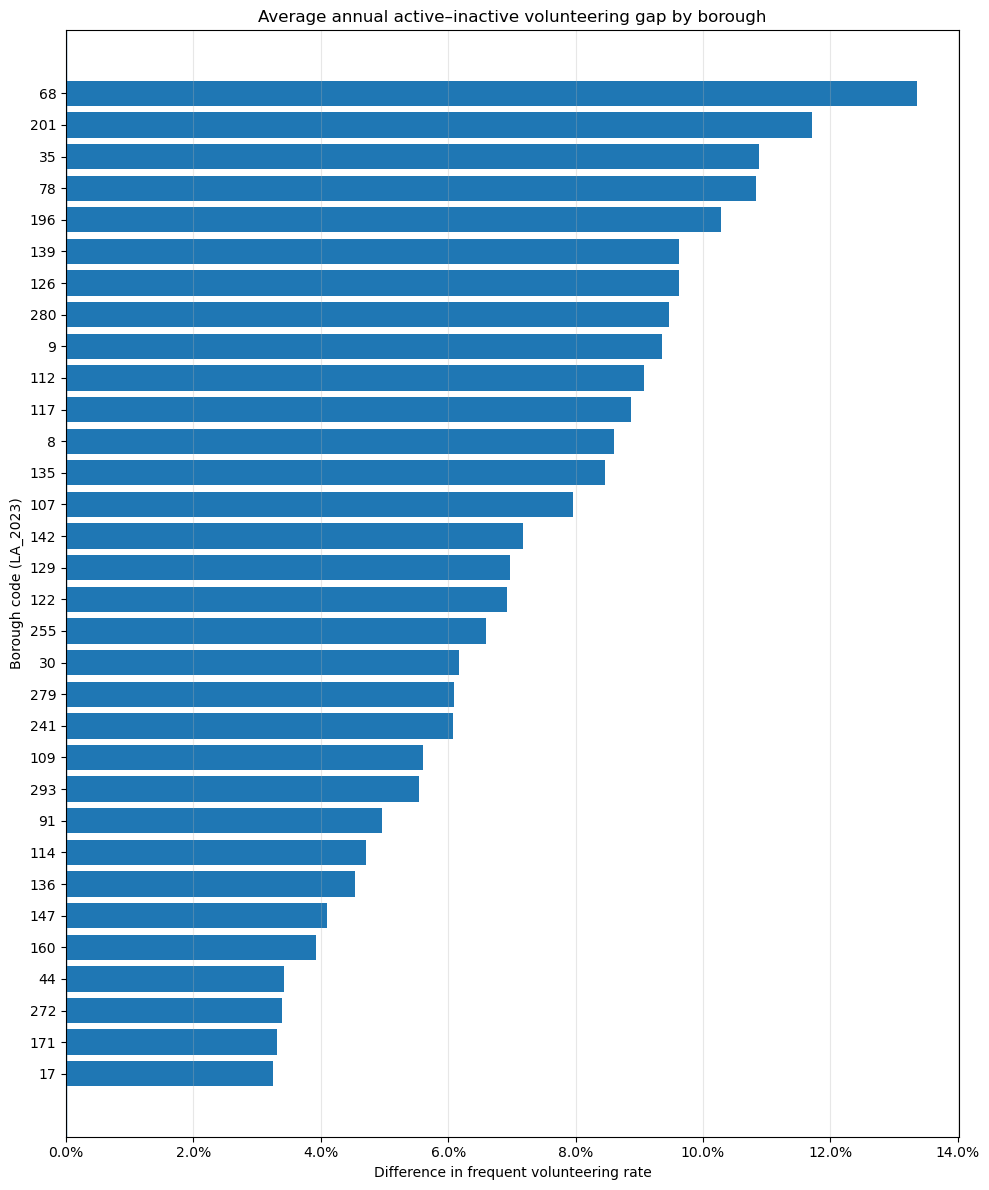

In [18]:
borough_plot_data = (
    borough_gap_summary
    .sort_values(
        "average_active_inactive_gap"
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 12)
)

ax.barh(
    borough_plot_data[
        "LA_2023"
    ].astype(str),
    borough_plot_data[
        "average_active_inactive_gap"
    ],
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_title(
    "Average annual active–inactive "
    "volunteering gap by borough"
)

ax.set_xlabel(
    "Difference in frequent volunteering rate"
)

ax.set_ylabel(
    "Borough code (LA_2023)"
)

ax.xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax.grid(
    axis="x",
    alpha=0.3,
)

fig.tight_layout()

save_figure(
    fig,
    "figure_06_borough_active_"
    "inactive_gap.png",
)

plt.show()

Figure 7

Saved figure: descriptive_figures/figure_07_borough_distribution_inactive.png


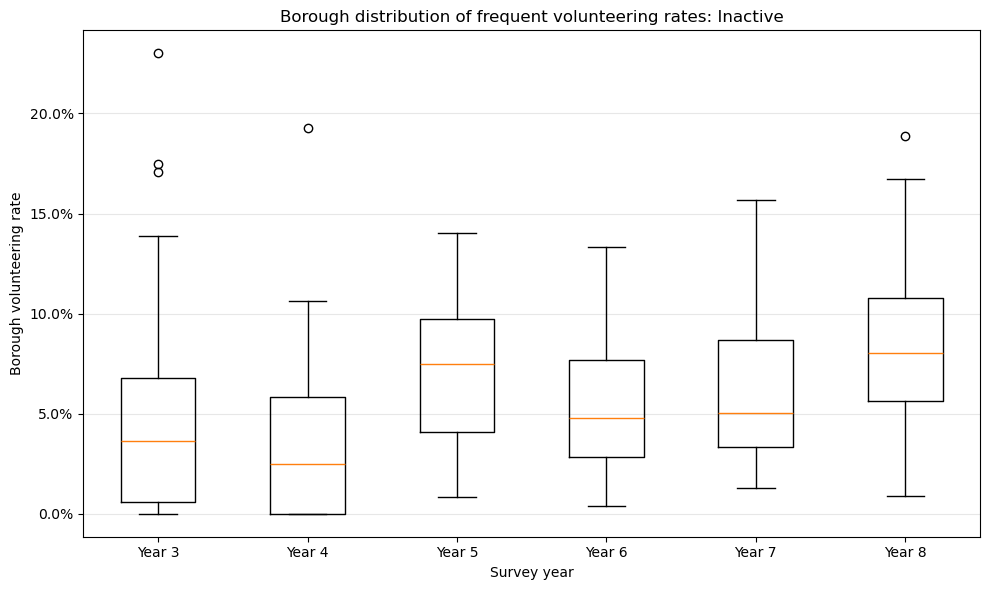

Saved figure: descriptive_figures/figure_07_borough_distribution_fairly_active.png


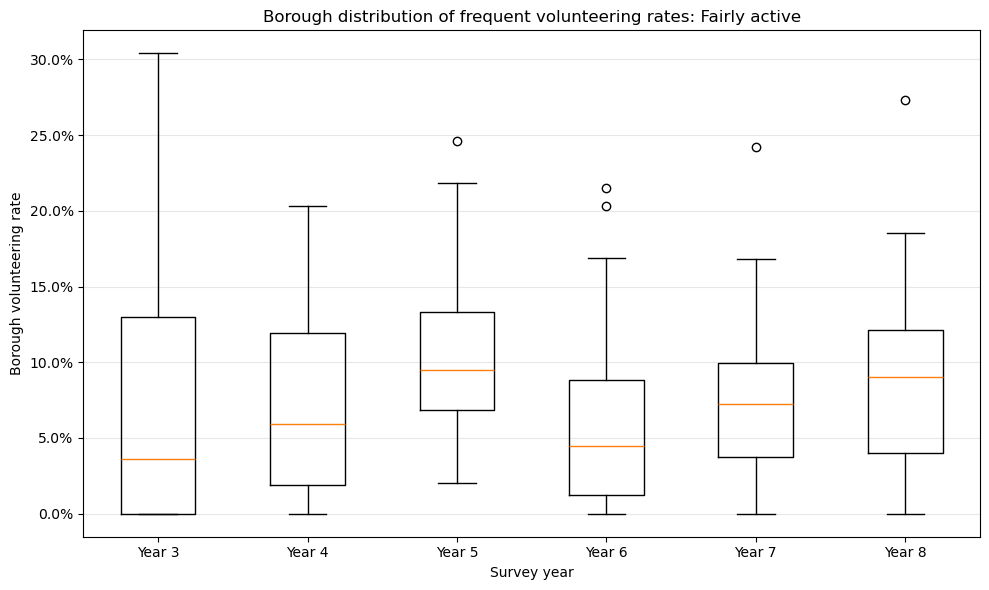

Saved figure: descriptive_figures/figure_07_borough_distribution_active.png


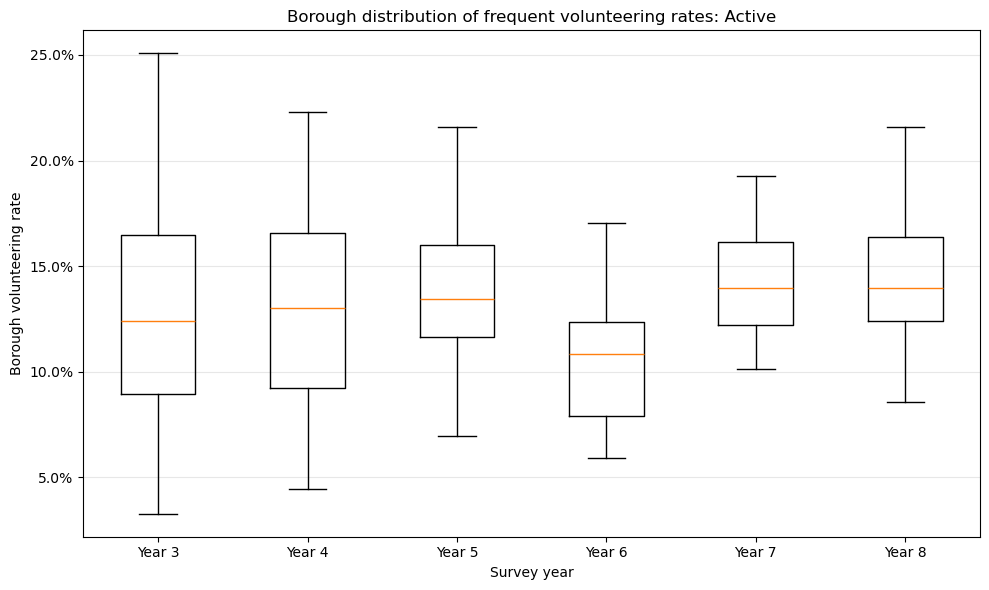

In [19]:
for activity_level in ACTIVITY_ORDER:
    subset = (
        borough_year_activity.loc[
            borough_year_activity[
                "activity_level_3cat_label"
            ]
            == activity_level
        ]
        .copy()
    )

    yearly_values = [
        subset.loc[
            subset["year"] == year,
            "frequent_volunteer_rate",
        ]
        .dropna()
        .to_numpy()
        for year in YEAR_ORDER
    ]

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.boxplot(
        yearly_values
    )

    ax.set_xticks(
        range(
            1,
            len(YEAR_ORDER) + 1,
        )
    )

    ax.set_xticklabels(
        [
            YEAR_LABELS[year]
            for year in YEAR_ORDER
        ]
    )

    ax.set_title(
        "Borough distribution of frequent "
        f"volunteering rates: "
        f"{ACTIVITY_DISPLAY[activity_level]}"
    )

    ax.set_xlabel(
        "Survey year"
    )

    ax.set_ylabel(
        "Borough volunteering rate"
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    ax.grid(
        axis="y",
        alpha=0.3,
    )

    fig.tight_layout()

    save_figure(
        fig,
        (
            "figure_07_borough_distribution_"
            f"{activity_level}.png"
        ),
    )

    plt.show()

In [20]:
series_coverage = (
    complete_panel[
        [
            "series_id",
            "observed_years_in_series",
            "series_coverage_rate",
            "series_has_history",
            "series_complete_history",
        ]
    ]
    .drop_duplicates(
        subset="series_id"
    )
)

series_coverage_summary = (
    series_coverage[
        "observed_years_in_series"
    ]
    .value_counts()
    .reindex(
        range(0, 7),
        fill_value=0,
    )
    .rename_axis(
        "observed_years"
    )
    .reset_index(
        name="number_of_series"
    )
)

series_coverage_summary[
    "percentage_of_series"
] = (
    series_coverage_summary[
        "number_of_series"
    ]
    / len(series_coverage)
)

series_coverage_summary

,observed_years,number_of_series,percentage_of_series
0,0,10,0.013021
1,1,16,0.020833
2,2,30,0.039062
3,3,23,0.029948
4,4,33,0.042969
5,5,86,0.111979
6,6,570,0.742188


Figure 8

Saved figure: descriptive_figures/figure_08_series_coverage.png


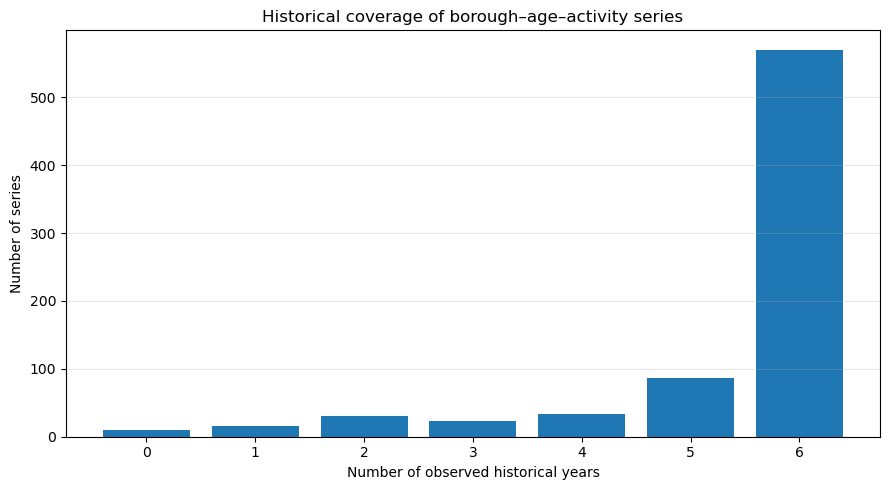

In [21]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    series_coverage_summary[
        "observed_years"
    ],
    series_coverage_summary[
        "number_of_series"
    ],
)

ax.set_title(
    "Historical coverage of "
    "borough–age–activity series"
)

ax.set_xlabel(
    "Number of observed historical years"
)

ax.set_ylabel(
    "Number of series"
)

ax.set_xticks(
    range(0, 7)
)

ax.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

save_figure(
    fig,
    "figure_08_series_coverage.png",
)

plt.show()

In [22]:
output_tables = {
    "q5_dataset_overview.csv":
        dataset_overview,
    "q5_cell_quality_overview.csv":
        cell_quality_overview,
    "q5_quality_by_age_activity.csv":
        quality_by_age_activity,
    "q5_london_year_activity.csv":
        london_year_activity,
    "q5_age_year_activity.csv":
        age_year_activity,
    "q5_age_activity_average.csv":
        age_activity_average,
    "q5_age_activity_gaps.csv":
        age_rate_wide,
    "q5_borough_year_activity.csv":
        borough_year_activity,
    "q5_borough_gap_summary.csv":
        borough_gap_summary,
    "q5_series_coverage_summary.csv":
        series_coverage_summary,
}

for filename, dataframe in (
    output_tables.items()
):
    output_path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved table: "
        f"{output_path}"
    )

Saved table: descriptive_tables/q5_dataset_overview.csv
Saved table: descriptive_tables/q5_cell_quality_overview.csv
Saved table: descriptive_tables/q5_quality_by_age_activity.csv
Saved table: descriptive_tables/q5_london_year_activity.csv
Saved table: descriptive_tables/q5_age_year_activity.csv
Saved table: descriptive_tables/q5_age_activity_average.csv
Saved table: descriptive_tables/q5_age_activity_gaps.csv
Saved table: descriptive_tables/q5_borough_year_activity.csv
Saved table: descriptive_tables/q5_borough_gap_summary.csv
Saved table: descriptive_tables/q5_series_coverage_summary.csv


In [23]:
rate_tables = {
    "London trend":
        london_year_activity[
            "frequent_volunteer_rate"
        ],
    "Age trends":
        age_year_activity[
            "frequent_volunteer_rate"
        ],
    "Borough trends":
        borough_year_activity[
            "frequent_volunteer_rate"
        ],
}

for table_name, rates in rate_tables.items():
    if not rates.dropna().between(
        0,
        1,
    ).all():
        raise ValueError(
            f"Invalid rate found in "
            f"{table_name}."
        )

print(
    "All descriptive rate checks passed."
)

print(
    f"Figures saved to: "
    f"{FIGURE_DIR}"
)

print(
    f"Tables saved to: "
    f"{TABLE_DIR}"
)

All descriptive rate checks passed.
Figures saved to: descriptive_figures
Tables saved to: descriptive_tables
